dataset: https://www.kaggle.com/datasets/omarsobhy14/5g-quality-of-service/data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import re
import statsmodels.formula.api as sm


In [ ]:
data = pd.read_csv("Quality of Service 5G.csv")
data.describe()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
count,400,400,400,400,400,400,400,400
unique,7,400,11,84,87,188,194,9
top,9/3/2023 10:01,User_384,Video_Call,-85 dBm,5 ms,0.1 Mbps,0.1 Mbps,70%
freq,60,1,58,9,35,16,16,148


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Timestamp            400 non-null    object
 1   User_ID              400 non-null    object
 2   Application_Type     400 non-null    object
 3   Signal_Strength      400 non-null    object
 4   Latency              400 non-null    object
 5   Required_Bandwidth   400 non-null    object
 6   Allocated_Bandwidth  400 non-null    object
 7   Resource_Allocation  400 non-null    object
dtypes: object(8)
memory usage: 25.1+ KB


# **Preprocessing**

In [ ]:
cols = [
    'Allocated_Bandwidth',
    'Latency',
    'Required_Bandwidth',
    'Signal_Strength',
    'Resource_Allocation'
]

data[cols] = data[cols].replace(r'[^\d\.-]', '', regex=True).astype(float)


data['Resource_Allocation'] /= 100

In [ ]:
data = data.drop(columns=['Timestamp', 'User_ID'], axis=1)

In [ ]:
data.isna().sum()

,0
Application_Type,0
Signal_Strength,0
Latency,0
Required_Bandwidth,0
Allocated_Bandwidth,0
Resource_Allocation,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Application_Type     400 non-null    object 
 1   Signal_Strength      400 non-null    float64
 2   Latency              400 non-null    float64
 3   Required_Bandwidth   400 non-null    float64
 4   Allocated_Bandwidth  400 non-null    float64
 5   Resource_Allocation  400 non-null    float64
dtypes: float64(5), object(1)
memory usage: 18.9+ KB


In [ ]:
data.describe()

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,-80.495000,33.825000,77.573500,80.805000,0.747125
std,20.701119,21.122139,178.382278,178.881247,0.089823
min,-123.000000,0.000000,0.000000,0.000000,0.500000
25%,-98.000000,21.750000,1.100000,1.675000,0.700000
50%,-83.000000,31.000000,4.000000,4.400000,0.700000
75%,-64.000000,45.000000,13.125000,15.000000,0.800000
max,-40.000000,110.000000,690.000000,690.000000,0.900000


# **1. Estimation of the unconditional and conditional probabilities**


**Unconditional probabilities**


*   P(Application_Type)
*   P(Resourse_Allocation)




In [ ]:
analysis = data[['Application_Type', 'Signal_Strength', 'Latency', 'Resource_Allocation']]
bins = [0, 0.6, 0.8, 1]
labels = ['Low', 'Medium', 'High']
analysis['Res_Allocation_Category'] = pd.cut(analysis['Resource_Allocation'], bins=bins, labels=labels, include_lowest=True)

bins = [-np.inf, -98, -80, np.inf]
analysis['Strength_Category'] = pd.cut(analysis['Signal_Strength'], bins=bins, labels=labels)


bins = [-np.inf, 20, 45, np.inf]
analysis['Latency_Category'] = pd.cut(analysis['Latency'], bins=bins, labels=labels)

/tmp/ipython-input-503087786.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis['Res_Allocation_Category'] = pd.cut(analysis['Resource_Allocation'], bins=bins, labels=labels, include_lowest=True)


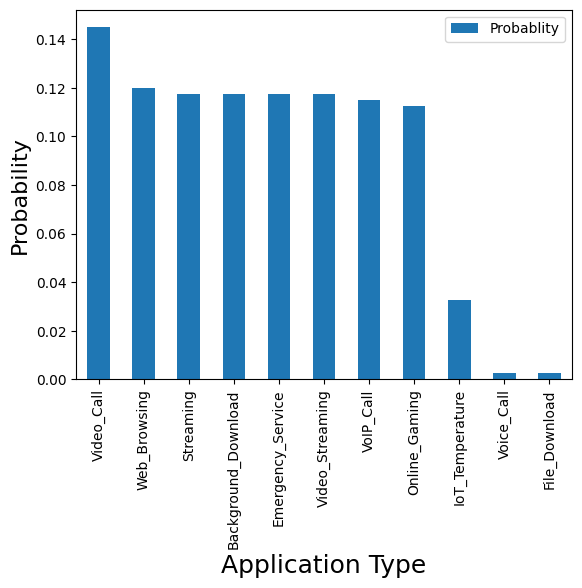

                     Probablity
Application_Type               
Video_Call               0.1450
Web_Browsing             0.1200
Streaming                0.1175
Background_Download      0.1175
Emergency_Service        0.1175
Video_Streaming          0.1175
VoIP_Call                0.1150
Online_Gaming            0.1125
IoT_Temperature          0.0325
Voice_Call               0.0025
File_Download            0.0025


In [ ]:
P_app_type = pd.DataFrame(analysis['Application_Type'].value_counts()/len(analysis))
P_app_type.columns = ['Probablity']
P_app_type.plot.bar()
plt.ylabel("Probability",fontsize=16)
plt.xlabel("Application Type",fontsize=18)
plt.show()
print(P_app_type)

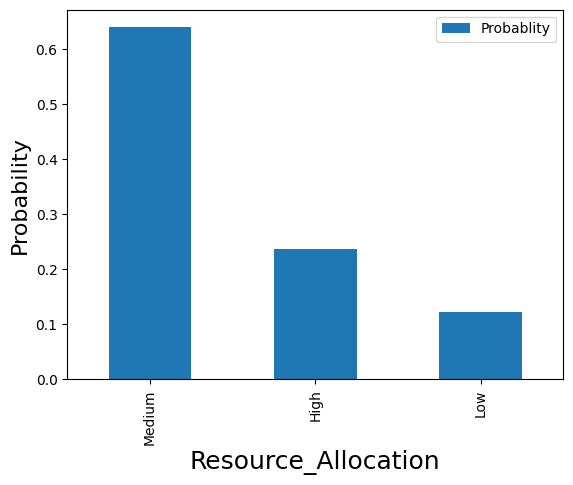

                         Probablity
Res_Allocation_Category            
Medium                       0.6400
High                         0.2375
Low                          0.1225


In [ ]:
P_res_alloc = pd.DataFrame(analysis['Res_Allocation_Category'].value_counts()/len(analysis))
P_res_alloc.columns = ['Probablity']
P_res_alloc.plot.bar()
plt.ylabel("Probability",fontsize=16)
plt.xlabel("Resource_Allocation",fontsize=18)
plt.show()
print(P_res_alloc)

**Conditional Probabilities**



*   P(High Latency | Resource Allocation Category)
*   P(Resource Allocation Category| Application Type)

In [ ]:
analysis

,Application_Type,Signal_Strength,Latency,Resource_Allocation,Res_Allocation_Category,Strength_Category,Latency_Category
0,Video_Call,-75.0,30.0,0.70,Medium,High,Medium
1,Voice_Call,-80.0,20.0,0.80,Medium,Medium,Low
2,Streaming,-85.0,40.0,0.75,Medium,Medium,Medium
3,Emergency_Service,-70.0,10.0,0.90,High,High,Low
4,Online_Gaming,-78.0,25.0,0.85,High,High,Medium
...,...,...,...,...,...,...,...
395,Streaming,-110.0,61.0,0.85,High,Low,High
396,Video_Call,-40.0,53.0,0.75,Medium,High,High
397,Video_Streaming,-113.0,58.0,0.70,Medium,Low,High
398,Emergency_Service,-40.0,5.0,0.70,Medium,High,Low


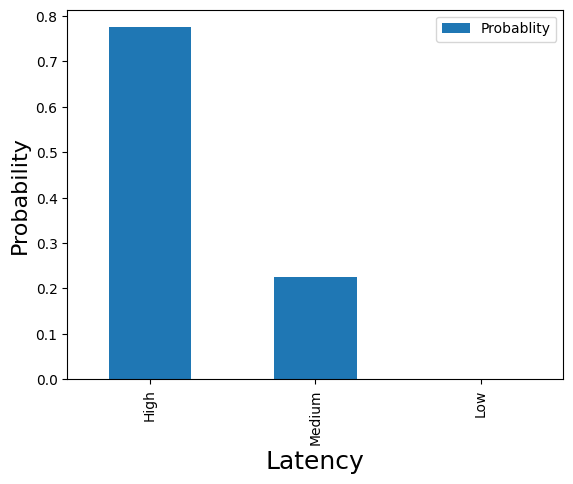

                  Probablity
Latency_Category            
High                 0.77551
Medium               0.22449
Low                  0.00000


In [ ]:
low_Alloc = analysis[analysis['Res_Allocation_Category'] == 'Low']
P_Latency_LAlloc = pd.DataFrame(low_Alloc['Latency_Category'].value_counts()/len(low_Alloc))
P_Latency_LAlloc.columns = ['Probablity']
P_Latency_LAlloc.plot.bar()
plt.ylabel("Probability",fontsize=16)
plt.xlabel("Latency",fontsize=18)
plt.show()
print(P_Latency_LAlloc)

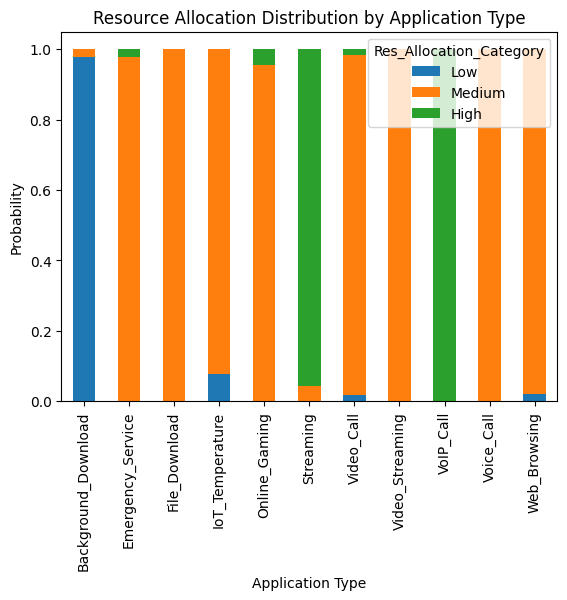

Res_Allocation_Category       Low    Medium      High
Application_Type                                     
Background_Download      0.978723  0.021277  0.000000
Emergency_Service        0.000000  0.978723  0.021277
File_Download            0.000000  1.000000  0.000000
IoT_Temperature          0.076923  0.923077  0.000000
Online_Gaming            0.000000  0.955556  0.044444
Streaming                0.000000  0.042553  0.957447
Video_Call               0.017241  0.965517  0.017241
Video_Streaming          0.000000  1.000000  0.000000
VoIP_Call                0.000000  0.000000  1.000000
Voice_Call               0.000000  1.000000  0.000000
Web_Browsing             0.020833  0.979167  0.000000


In [ ]:
P_Alloc_App = pd.crosstab(analysis['Application_Type'], analysis['Res_Allocation_Category'], normalize='index')

P_Alloc_App.plot.bar(stacked=True)
plt.ylabel("Probability")
plt.xlabel("Application Type")
plt.title("Resource Allocation Distribution by Application Type")
plt.show()
print(P_Alloc_App)

# **2. Estimation of the parameters of the joint distributions**

In [ ]:
data_num  = data.drop('Application_Type', axis=1)
cov_matrix = data_num.cov()
corr_matrix = data_num.corr()

print('Covariance matrix: \n')
cov_matrix


Covariance matrix: 



,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
Signal_Strength,428.536316,-171.698371,-1403.446985,-1394.533358,0.564488
Latency,-171.698371,446.144737,1265.306128,1257.785088,-0.261532
Required_Bandwidth,-1403.446985,1265.306128,31820.237241,31878.441236,-7.931693
Allocated_Bandwidth,-1394.533358,1257.785088,31878.441236,31998.500476,-7.530763
Resource_Allocation,0.564488,-0.261532,-7.931693,-7.530763,0.008068


In [ ]:
print('Correlation Matrix: \n')
corr_matrix

Correlation Matrix: 



,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
Signal_Strength,1.000000,-0.392676,-0.380059,-0.376591,0.303580
Latency,-0.392676,1.000000,0.335820,0.332892,-0.137848
Required_Bandwidth,-0.380059,0.335820,1.000000,0.999035,-0.495025
Allocated_Bandwidth,-0.376591,0.332892,0.999035,1.000000,-0.468691
Resource_Allocation,0.303580,-0.137848,-0.495025,-0.468691,1.000000


# **3. Estimation of confidence intervals of Mathematical Expectation**
Since the variance is unknown, we will reduce to the Student t-distribution to calculate the confidence intervals for mathematical expectation.

In [ ]:
alpha = 0.05 #95% confidence

sample = data['Latency']
n = len(sample)
mean = sample.mean()
std = sample.std(ddof=1)

# t critical value
t_crit = stats.t.ppf(1 - alpha/2, df=n-1) #1 - alpha/2 - order of the needed quantile, df - degrees of freedom

# Margin of error
margin = t_crit * std / np.sqrt(n)

ci_latency = (mean - margin, mean + margin)
print("95% confidence interval for mean latency: ", ci_latency)

95% confidence interval for mean latency:  (np.float64(31.7487705640105), np.float64(35.90122943598951))


In [ ]:
sample = data['Resource_Allocation']
n = len(sample)
mean = sample.mean()
std = sample.std(ddof=1)

ci_res_alloc = stats.t.interval(
    1-alpha,
    df=n-1,
    loc=mean,
    scale=std/np.sqrt(n)
)
print("95% confidence interval for mean resource allocation: ", ci_res_alloc)

95% confidence interval for mean resource allocation:  (np.float64(0.738295734689898), np.float64(0.7559542653101021))


# **4. Parametric Hypothesis Testing**

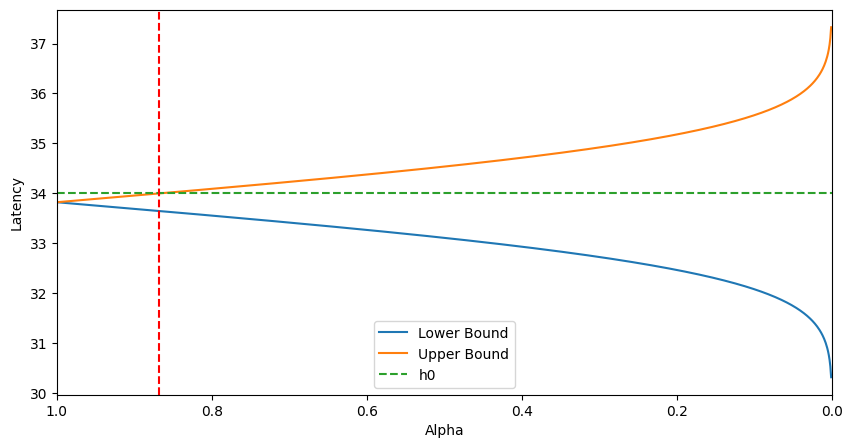

p-value =  0.8678678678678678


In [ ]:
#Testing the mean
#Hypothesis (H0) E(latency) = 34, (H1) E(latency) != 34
#Confidence intervals with significance level (alpha) = 0.05
#Check H0:
sample = data['Latency']
h0 = 34
n = len(sample)
mean = sample.mean()
std = sample.std(ddof=1)

a = np.linspace(1, 0, 1000)

lb_list = [] #lower bound
ub_list = [] #upper bound

p_value = None  # To track when p-value enters the interval

for alpha in a:
    lb, ub = stats.t.interval(1 - alpha, df=n - 1, loc=mean, scale=std/np.sqrt(n))

    lb_list.append(lb)
    ub_list.append(ub)

    if p_value is None and lb <= h0 <= ub:
        p_value = alpha


plt.figure(figsize=(10, 5))
plt.plot(a, lb_list, label='Lower Bound')
plt.plot(a, ub_list, label='Upper Bound')
plt.plot(a, [h0] * len(a), label='h0', linestyle='dashed')

plt.xlabel('Alpha')
plt.ylabel('Latency')
plt.legend()

plt.axvline(x=p_value, color='r', linestyle='--')

plt.xlim(1, 0)
plt.show()
print('p-value = ', p_value)

In [ ]:
margin = np.abs(mean - 34)
Quantile = margin * (np.sqrt(n) / std)
p_value = 2*(1-stats.t.cdf(Quantile,df=n-1))
p_value

np.float64(0.8684746758849595)

The p-value for testing H0: E(Latency)=34 is 0.87. This means that the observed sample mean is highly consistent with the null hypothesis. Therefore, we fail to reject H0.

# **5. Regression Analysis**
As the main dependent variable I take the Allocated_Bandwidth, since it was derived by the AI algorythm from other variables.

In [ ]:
corr_matrix

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
Signal_Strength,1.000000,-0.392676,-0.380059,-0.376591,0.303580
Latency,-0.392676,1.000000,0.335820,0.332892,-0.137848
Required_Bandwidth,-0.380059,0.335820,1.000000,0.999035,-0.495025
Allocated_Bandwidth,-0.376591,0.332892,0.999035,1.000000,-0.468691
Resource_Allocation,0.303580,-0.137848,-0.495025,-0.468691,1.000000


**Linear Regression**

REQUIRED BANDWIDTH SUMMARY: 
                              OLS Regression Results                            
Dep. Variable:     Allocated_Bandwidth   R-squared:                       0.998
Model:                             OLS   Adj. R-squared:                  0.998
Method:                  Least Squares   F-statistic:                 2.058e+05
Date:                 Thu, 15 Jan 2026   Prob (F-statistic):               0.00
Time:                         14:20:19   Log-Likelihood:                -1391.7
No. Observations:                  400   AIC:                             2787.
Df Residuals:                      398   BIC:                             2795.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

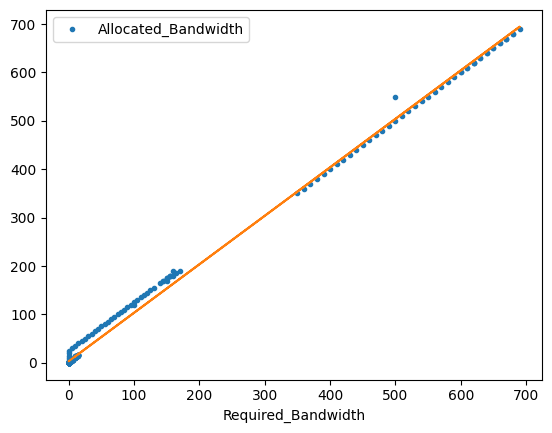

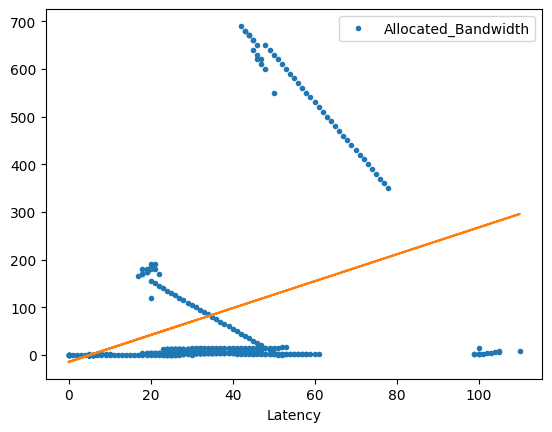

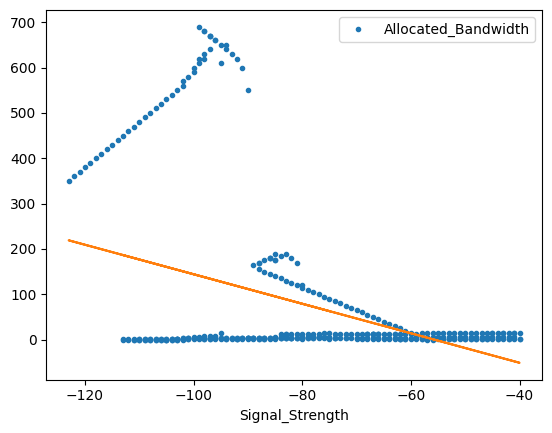

In [ ]:
y = 'Allocated_Bandwidth'
linReg_req_alloc = sm.ols('Allocated_Bandwidth ~ Required_Bandwidth', data).fit() #ols -- ordinary least squares
data.plot('Required_Bandwidth', y, style='.')
plt.plot(data.Required_Bandwidth, linReg_req_alloc.fittedvalues)
print('REQUIRED BANDWIDTH SUMMARY: \n', linReg_req_alloc.summary())

linReg_late_alloc = sm.ols('Allocated_Bandwidth ~ Latency', data).fit()
data.plot('Latency', y, style='.')
plt.plot(data.Latency, linReg_late_alloc.fittedvalues)
print('\n\nLATENCY SUMMARY: \n', linReg_late_alloc.summary())

linReg_str_alloc = sm.ols('Allocated_Bandwidth ~ Signal_Strength', data).fit()
data.plot('Signal_Strength', y, style='.')
plt.plot(data.Signal_Strength, linReg_str_alloc.fittedvalues)
print('\n\nSIGNAL STRENGTH SUMMARY: \n', linReg_str_alloc.summary())

We can see branching on the Latency and Signal Strength graphs, which means that there is a hidden grouping. In this case we should account for the Application Type for clear analysis.

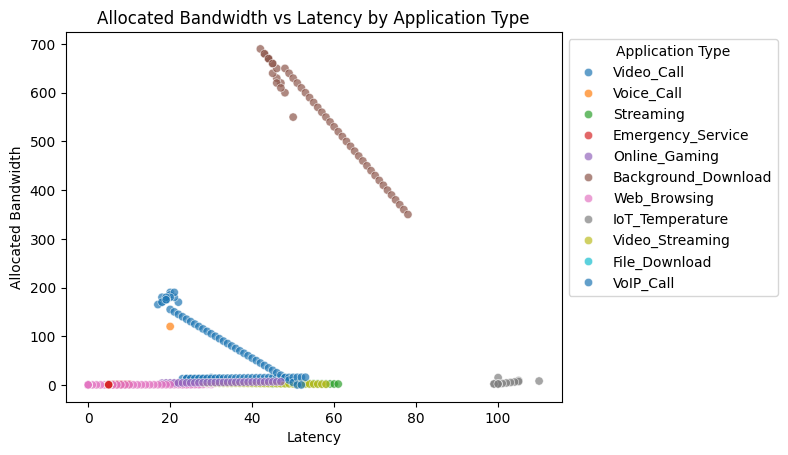

In [ ]:
# Latency
sns.scatterplot(
    x='Latency',
    y = y,
    hue='Application_Type',
    data=data,
    palette='tab10',
    alpha=0.7 #opacity
)
plt.title('Allocated Bandwidth vs Latency by Application Type')
plt.xlabel('Latency')
plt.ylabel('Allocated Bandwidth')
plt.legend(title='Application Type', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

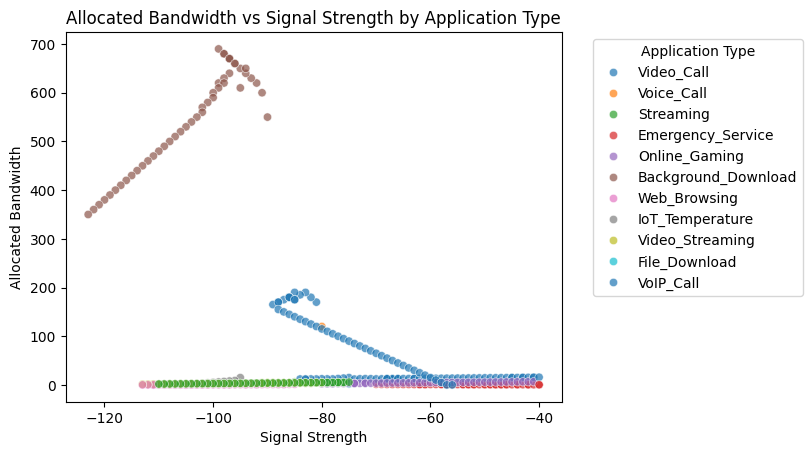

In [ ]:
# Signal Strength
sns.scatterplot(
    x='Signal_Strength',
    y=y,
    hue='Application_Type',
    data=data,
    palette='tab10',
    alpha=0.7
)
plt.title('Allocated Bandwidth vs Signal Strength by Application Type')
plt.xlabel('Signal Strength')
plt.ylabel('Allocated Bandwidth')
plt.legend(title='Application Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

As we can see the 'Background_Download' and 'VoIP_Call' (Voice over IP) categories deviate from others the most.

**Nonlinear Regression**

In [ ]:
background = data[data['Application_Type'] == 'Background_Download']

w2 = [ 9.04736622e+02 -3.45340254e+00 -4.71768006e-02]


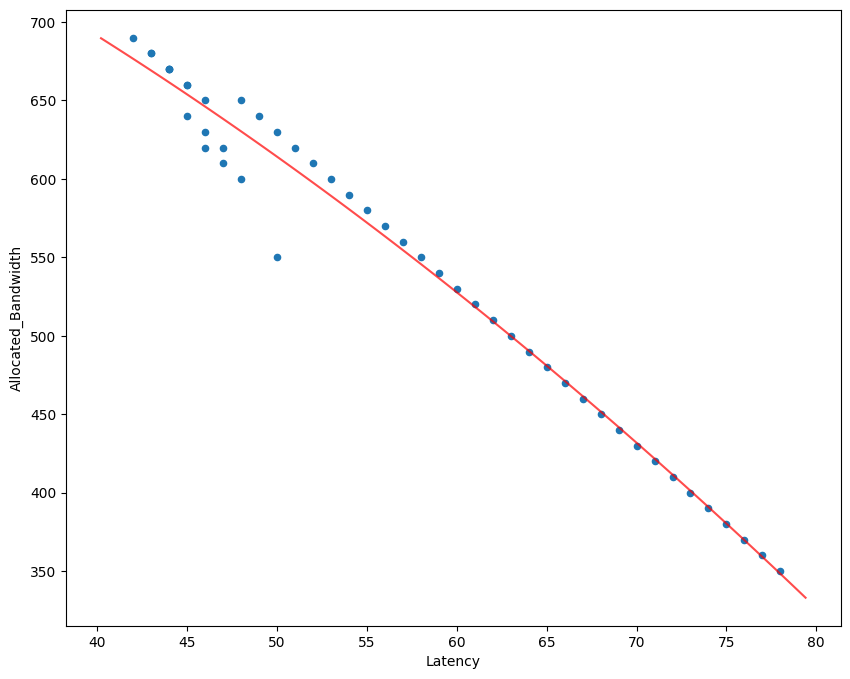

In [ ]:
#Quadratic
A=np.array(background['Latency'])
A=np.array([np.ones(len(A)), A, A**2]) #matrix[1, xi, xi ** 2] for quadratic equation
y=np.array(background['Allocated_Bandwidth'])

w2 = np.linalg.lstsq(A.T, y)[0] #returns least squares solution (A.T -- transposed matrix)
print('w2 =', w2)

def f2(x,w):
    return w[0] + w[1] * x + w[2] * x ** 2

ax = background.plot(kind='scatter', x='Latency',y='Allocated_Bandwidth',figsize=[10,8], style='o')
x0,x1=plt.xlim()

interval = x1 - x0
X=np.arange(x0, x1, interval/100.)
ax.plot(X,f2(X, w2), 'r', alpha = 0.7)
plt.show()

w3 = [-3.86213892e+04 -1.11557215e+03 -1.04490871e+01 -3.21729929e-02]


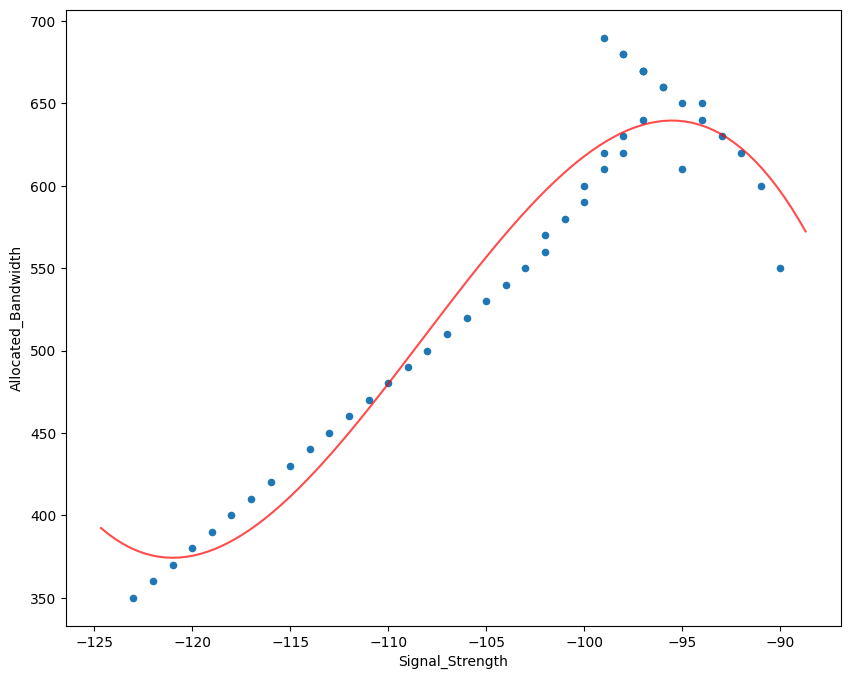

In [ ]:
#Qubic
A=np.array(background['Signal_Strength'])
A=np.array([np.ones(len(A)), A, A**2, A**3])
y=np.array(background['Allocated_Bandwidth'])

w3 = np.linalg.lstsq(A.T,y)[0]
print('w3 =', w3)
def f3(x,w):
    return w[0] + w[1]*x + w[2]*x**2 + w[3]*x**3

ax = background.plot(kind='scatter', x='Signal_Strength',y='Allocated_Bandwidth',figsize=[10,8], style='o')
x0, x1 = plt.xlim()

interval = x1 - x0
X=np.arange(x0,x1,interval/100.)
ax.plot(X, f3(X, w3), 'r', alpha = 0.7)
plt.show()

**Multiple Regression**

In [ ]:
model = ols("Allocated_Bandwidth ~ Latency * Signal_Strength", background).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Allocated_Bandwidth   R-squared:                       0.987
Model:                             OLS   Adj. R-squared:                  0.986
Method:                  Least Squares   F-statistic:                     1099.
Date:                 Thu, 15 Jan 2026   Prob (F-statistic):           1.21e-40
Time:                         14:20:21   Log-Likelihood:                -181.66
No. Observations:                   47   AIC:                             371.3
Df Residuals:                       43   BIC:                             378.7
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept       

It is important to notice that the combination of Latency and Strength gives very high coefficient of determination ($R^2$ = 0.987), while each variable taken separately shows only weak explanatory power:

$R^2$ = 0.142 (Signal_Strength)

$R^2$ = 0.111 (Latency)